In [1]:
import pathlib

import matplotlib.pyplot as plt
import pandas as pd

In [2]:
p = pathlib.Path("./annotations.parquet").resolve()

print("Exists:", p.exists())
print("Is file:", p.is_file())
print("Size (bytes):", p.stat().st_size)

with open(p, "rb") as f:
    print("First 4 bytes:", f.read(4))
# ...existing code...
p = pathlib.Path("./annotations.parquet").resolve()

with open(p, "rb") as f:
    f.seek(-4, 2)
    print("Last 4 bytes:", f.read(4))

Exists: True
Is file: True
Size (bytes): 2494
First 4 bytes: b'PAR1'
Last 4 bytes: b'PAR1'


In [3]:
annotations_file_path = pathlib.Path("./annotations.parquet").resolve()
annotations_df = pd.read_parquet(annotations_file_path)
annotations_df.head()

,image_filename,annotator,label,label_name,timestamp
0,NF0014_T1_C10-1_555_downsampled.png,Mike,1,globular,2026-02-11T08:46:14.379470
1,NF0014_T1_C4-1_555_downsampled.png,Mike,1,globular,2026-02-11T08:46:14.512983
2,NF0014_T1_C4-2_555_downsampled.png,Mike,1,globular,2026-02-11T08:46:14.522825
3,NF0014_T1_C5-1_555_downsampled.png,Mike,1,globular,2026-02-11T08:46:14.525918
4,NF0014_T1_C5-2_555_downsampled.png,Mike,1,globular,2026-02-11T08:46:14.528804


IndexError: too many indices for array: array is 1-dimensional, but 2 were indexed

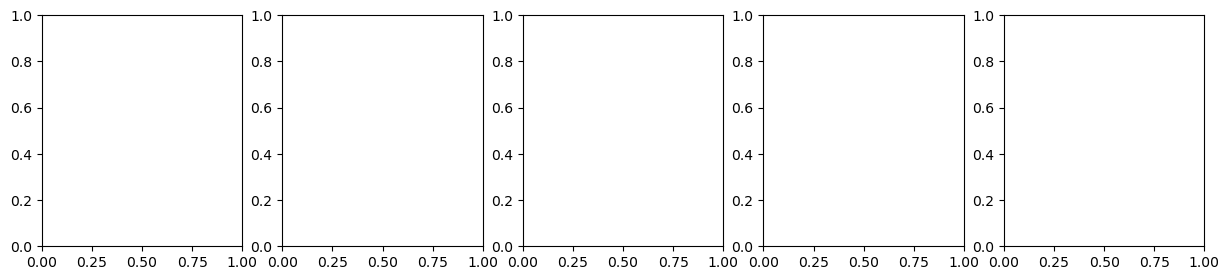

In [4]:
# get 5 random samples from the dataframe for each label and plot them in a grid
labels = annotations_df["label"].unique()
num_samples_per_label = 5
fig, axes = plt.subplots(
    len(labels), num_samples_per_label, figsize=(15, 3 * len(labels))
)
for i, label in enumerate(labels):
    label_df = annotations_df[annotations_df["label"] == label]
    samples = label_df.sample(num_samples_per_label, random_state=0)
    label_name = label_df["label_name"].iloc[0]
    for j, (_, row) in enumerate(samples.iterrows()):
        img_path = row["image_filename"]
        img_path = pathlib.Path(f"../data/compressed_images/{img_path}").resolve()
        img = plt.imread(img_path)
        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        axes[i, j].set_title(label_name, fontsize=12)
plt.tight_layout()
plt.show()